In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/eda_final_dataset.csv")

In [4]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,...,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Age_Group,Total_Late_Missed,OnTime_Count,Payment_Reliability_Score
0,cust0001,56,165580.0,398.0,0.390502,3,0,16310.0,0.317396,emp,...,late,late,missed,late,missed,late,Senior,0,0,0.0
1,cust0002,69,100999.0,493.0,0.312444,6,1,17401.0,0.196093,self-employed,...,missed,missed,late,missed,on-time,on-time,Retired,0,0,0.0
2,cust0003,46,188416.0,500.0,0.359930,0,0,13761.0,0.301655,self-employed,...,missed,late,late,on-time,missed,late,Mid Career,0,0,0.0
3,cust0004,32,101672.0,413.0,0.371400,3,0,88778.0,0.264794,unemployed,...,late,missed,late,missed,late,late,Early Career,0,0,0.0
4,cust0005,60,38524.0,487.0,0.234716,2,0,13316.0,0.510583,self-employed,...,missed,on-time,missed,late,late,late,Senior,0,0,0.0


In [5]:
print(df.shape)
print(df.columns.tolist())

(500, 23)
['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments', 'Delinquent_Account', 'Loan_Balance', 'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure', 'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6', 'Age_Group', 'Total_Late_Missed', 'OnTime_Count', 'Payment_Reliability_Score']


# Customer Credit Risk & Delinquency Analysis

## Business Problem

Financial institutions need to identify customers who are at a higher risk of becoming delinquent on their credit accounts. Understanding the relationship between customer financial behavior and delinquency helps improve lending decisions, reduce financial losses, and develop better risk management strategies.

## Objective

To analyze customer credit behavior, identify key factors associated with delinquency, and validate findings using statistical hypothesis testing.

In [6]:
# Count delinquent and non-delinquent customers
df['Delinquent_Account'].value_counts()

Delinquent_Account
0    420
1     80
Name: count, dtype: int64

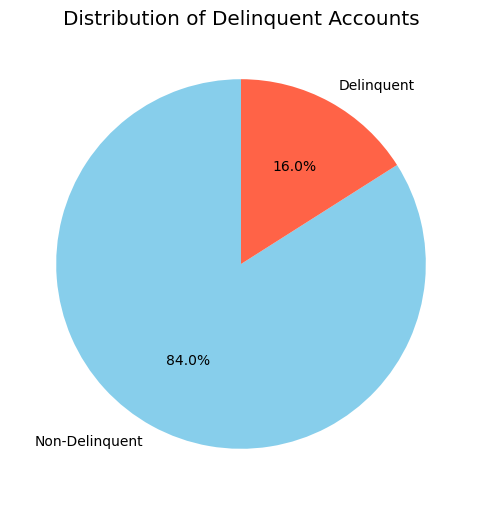

In [7]:
plt.figure(figsize=(6,6))

plt.pie(
    df['Delinquent_Account'].value_counts(),
    labels=['Non-Delinquent','Delinquent'],
    autopct='%1.1f%%',
    colors=['skyblue','tomato'],
    startangle=90
)

plt.title("Distribution of Delinquent Accounts")
plt.show()

## Business Insight 1

The dataset contains 500 customers.

Approximately 84% of customers are non-delinquent, while only 16% are delinquent.

This indicates that most customers maintain healthy credit behavior, while a smaller segment represents potential credit risk.

In [8]:
# Separate customers into two groups

non_delinquent = df[df['Delinquent_Account'] == 0]['Credit_Score']

delinquent = df[df['Delinquent_Account'] == 1]['Credit_Score']

In [9]:
print("Non-Delinquent Customers:", len(non_delinquent))
print("Delinquent Customers:", len(delinquent))

Non-Delinquent Customers: 420
Delinquent Customers: 80


In [10]:
print("Average Credit Score (Non-Delinquent):", round(non_delinquent.mean(), 2))
print("Average Credit Score (Delinquent):", round(delinquent.mean(), 2))

Average Credit Score (Non-Delinquent): 575.2
Average Credit Score (Delinquent): 591.15


In [11]:
from scipy.stats import ttest_ind

In [12]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    non_delinquent,
    delinquent,
    equal_var=False
)

print("T-Statistic :", round(t_stat, 4))
print("P-Value     :", round(p_value, 4))

T-Statistic : -0.7595
P-Value     : 0.4492


In [13]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
    print("There is a statistically significant difference in Credit Scores.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is NO statistically significant difference in Credit Scores.")

Fail to Reject the Null Hypothesis
There is NO statistically significant difference in Credit Scores.


## Business Insight 2: Credit Score Comparison

An independent t-test was conducted to compare the average credit scores of delinquent and non-delinquent customers.

- T-Statistic = -0.7595
- P-Value = 0.4492

Since the p-value (0.4492) is greater than the significance level (0.05), we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference in average credit scores between delinquent and non-delinquent customers in this dataset.

Therefore, credit score alone may not be a strong indicator of customer delinquency, and additional financial variables should be considered for risk assessment.

In [15]:
# Separate income by delinquency status

income_non = df[df['Delinquent_Account'] == 0]['Income']
income_del = df[df['Delinquent_Account'] == 1]['Income']

print("Average Income (Non-Delinquent):", round(income_non.mean(), 2))
print("Average Income (Delinquent):", round(income_del.mean(), 2))

Average Income (Non-Delinquent): 107335.36
Average Income (Delinquent): 113511.76


In [16]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    income_non,
    income_del,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 4))

T-Statistic: -0.9862
P-Value: 0.3262


## Business Insight 3: Income Comparison

An independent t-test was performed to compare the average income of delinquent and non-delinquent customers.

- Average Income (Non-Delinquent): 107,335.36
- Average Income (Delinquent): 113,511.76
- T-Statistic: -0.9862
- P-Value: 0.3262

Since the p-value (0.3262) is greater than the significance level (0.05), we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference in income between delinquent and non-delinquent customers. Income alone is not a sufficient predictor of customer delinquency in this dataset.

In [17]:
# Average Payment Reliability Score

reliability_non = df[df['Delinquent_Account'] == 0]['Payment_Reliability_Score']
reliability_del = df[df['Delinquent_Account'] == 1]['Payment_Reliability_Score']

print("Average Reliability (Non-Delinquent):", round(reliability_non.mean(), 2))
print("Average Reliability (Delinquent):", round(reliability_del.mean(), 2))

Average Reliability (Non-Delinquent): 0.0
Average Reliability (Delinquent): 0.0


In [18]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    reliability_non,
    reliability_del,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 4))

T-Statistic: nan
P-Value: nan


In [19]:
df['Payment_Reliability_Score'].describe()

count    500.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: Payment_Reliability_Score, dtype: float64

In [20]:
df['Payment_Reliability_Score'].value_counts()

Payment_Reliability_Score
0.0    500
Name: count, dtype: int64

In [21]:
df[['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6',
    'OnTime_Count','Total_Late_Missed','Payment_Reliability_Score']].head(10)

,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,OnTime_Count,Total_Late_Missed,Payment_Reliability_Score
0,late,late,missed,late,missed,late,0,0,0.0
1,missed,missed,late,missed,on-time,on-time,0,0,0.0
2,missed,late,late,on-time,missed,late,0,0,0.0
3,late,missed,late,missed,late,late,0,0,0.0
4,missed,on-time,missed,late,late,late,0,0,0.0
5,on-time,late,missed,missed,missed,late,0,0,0.0
6,on-time,missed,missed,late,missed,late,0,0,0.0
7,on-time,on-time,on-time,late,missed,late,0,0,0.0
8,on-time,on-time,on-time,missed,late,on-time,0,0,0.0
9,on-time,missed,missed,on-time,missed,missed,0,0,0.0


In [22]:
dti_non = df[df['Delinquent_Account'] == 0]['Debt_to_Income_Ratio']
dti_del = df[df['Delinquent_Account'] == 1]['Debt_to_Income_Ratio']

print("Average DTI (Non-Delinquent):", round(dti_non.mean(), 2))
print("Average DTI (Delinquent):", round(dti_del.mean(), 2))

Average DTI (Non-Delinquent): 0.3
Average DTI (Delinquent): 0.31


In [23]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(
    dti_non,
    dti_del,
    equal_var=False
)

print("T-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 4))

T-Statistic: -0.7996
P-Value: 0.4256


## Business Insight 4: Debt-to-Income Ratio Comparison

An independent t-test was performed to compare the Debt-to-Income Ratio between delinquent and non-delinquent customers.

**Results:**
- Average DTI (Non-Delinquent): **0.30**
- Average DTI (Delinquent): **0.31**
- T-Statistic: **-0.7996**
- P-Value: **0.4256**

**Conclusion:**

Since the p-value is greater than the significance level (0.05), we fail to reject the null hypothesis.

There is no statistically significant difference in the Debt-to-Income Ratio between delinquent and non-delinquent customers in this dataset.